<a href="https://colab.research.google.com/github/YASHK-arch/Yulu-Hypothesis-Case-Study-Notebook/blob/main/Yulu_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚲 Yulu – Micro-Mobility Demand Analysis
## Hypothesis Testing Case Study

**Objective:** Identify variables that significantly predict demand for shared electric cycles in the Indian market and perform a series of statistical hypothesis tests to derive actionable business insights.

---

## 1. Problem Statement, Library Imports & Exploratory Data Analysis

### 1.0 Problem Statement

Yulu has experienced a revenue decline and wants to understand **which variables significantly influence demand** for shared electric cycles in India. We will:
- Perform EDA to understand the data
- Run statistical tests (t-tests, chi-square) to validate hypotheses
- Check statistical assumptions (normality, variance equality)
- Build a linear regression model to quantify variable importance
- Provide data-driven recommendations


In [3]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Statistical Tests ────────────────────────────────────────────────────────
from scipy import stats
from scipy.stats import (
    ttest_1samp, ttest_ind, ttest_rel,
    chi2_contingency, chisquare, shapiro, levene
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# ── Settings ─────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 20)
ALPHA = 0.05
print('Libraries loaded ✅')

Libraries loaded ✅


### 1.1 Load the Dataset

In [4]:
df = pd.read_csv('yulu.csv')   # adjust path if needed
print('Shape:', df.shape)
df.head()

Shape: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


### 1.2 Dataset Structure & Statistical Summary

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [6]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


### 1.3 Parse DateTime & Engineer Features

In [7]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour']     = df['datetime'].dt.hour
df['day']      = df['datetime'].dt.day
df['month']    = df['datetime'].dt.month
df['year']     = df['datetime'].dt.year
df['weekday']  = df['datetime'].dt.weekday          # 0=Mon … 6=Sun
df['is_weekend'] = (df['weekday'] >= 5).astype(int) # 1 = weekend

season_map  = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
weather_map = {1:'Clear', 2:'Mist', 3:'Light Rain/Snow', 4:'Heavy Rain/Snow'}
df['season_label']  = df['season'].map(season_map)
df['weather_label'] = df['weather'].map(weather_map)

df[['datetime','hour','weekday','is_weekend','season_label','weather_label']].head()

,datetime,hour,weekday,is_weekend,season_label,weather_label
0,2011-01-01 00:00:00,0,5,1,Spring,Clear
1,2011-01-01 01:00:00,1,5,1,Spring,Clear
2,2011-01-01 02:00:00,2,5,1,Spring,Clear
3,2011-01-01 03:00:00,3,5,1,Spring,Clear
4,2011-01-01 04:00:00,4,5,1,Spring,Clear


### 1.4 Missing Values

In [8]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'None ✅')

Missing values per column:
None ✅


### 1.5 Duplicate Records

In [9]:
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(f'Duplicates removed. New shape: {df.shape}')

Duplicate rows: 0


### 1.6 Distribution of Numerical Variables

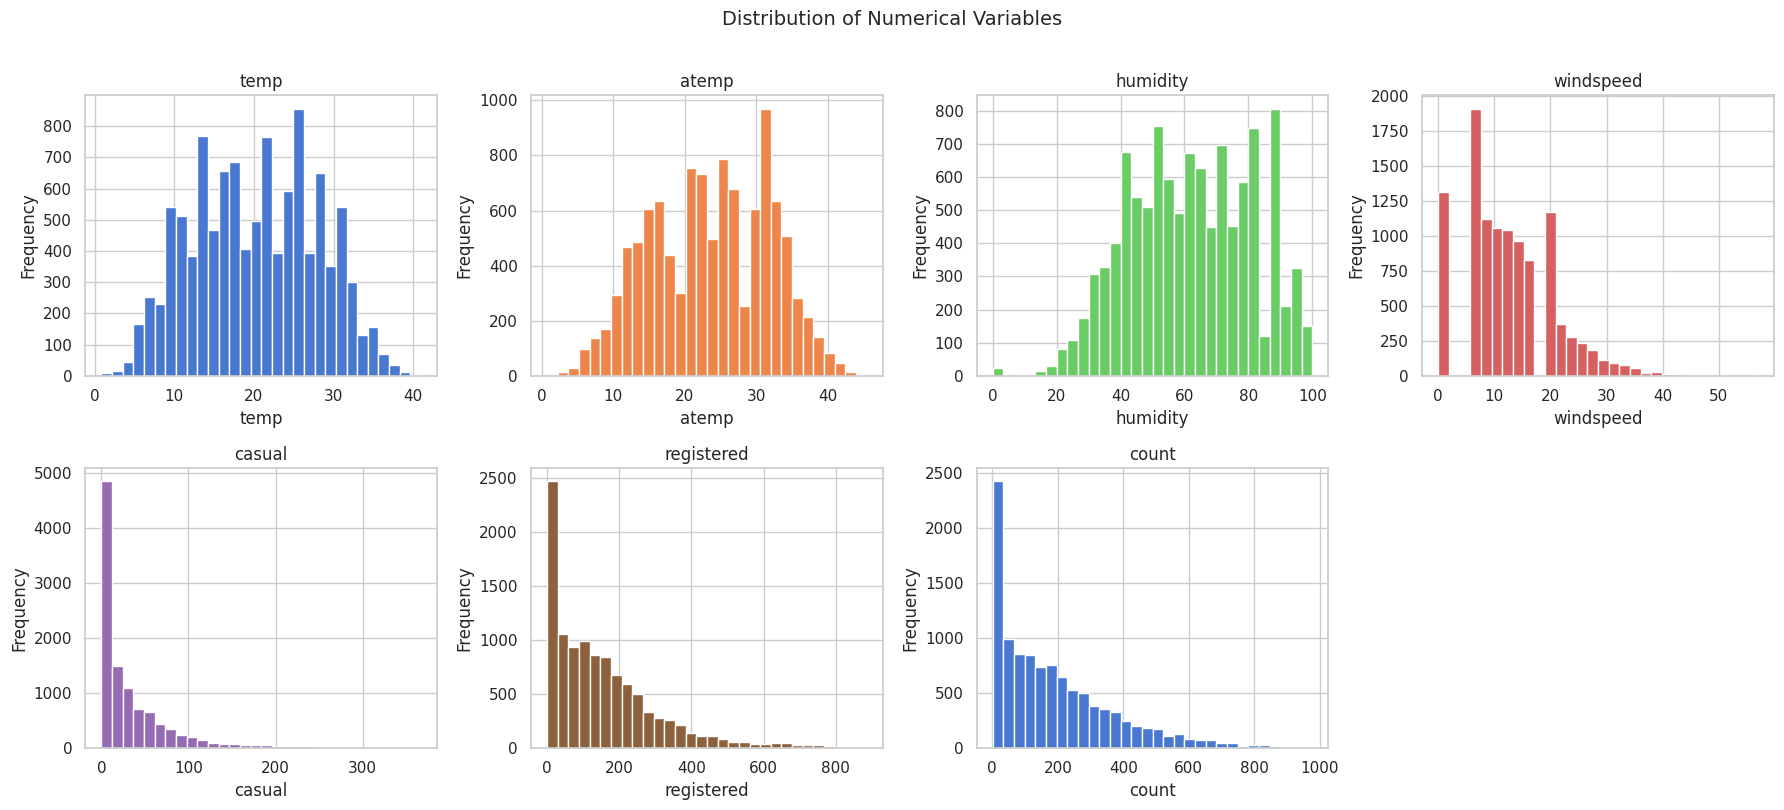

In [10]:
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, edgecolor='white', color=sns.color_palette('muted')[i % 6])
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].set_visible(False)
plt.suptitle('Distribution of Numerical Variables', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 1.7 Distribution of Categorical Variables

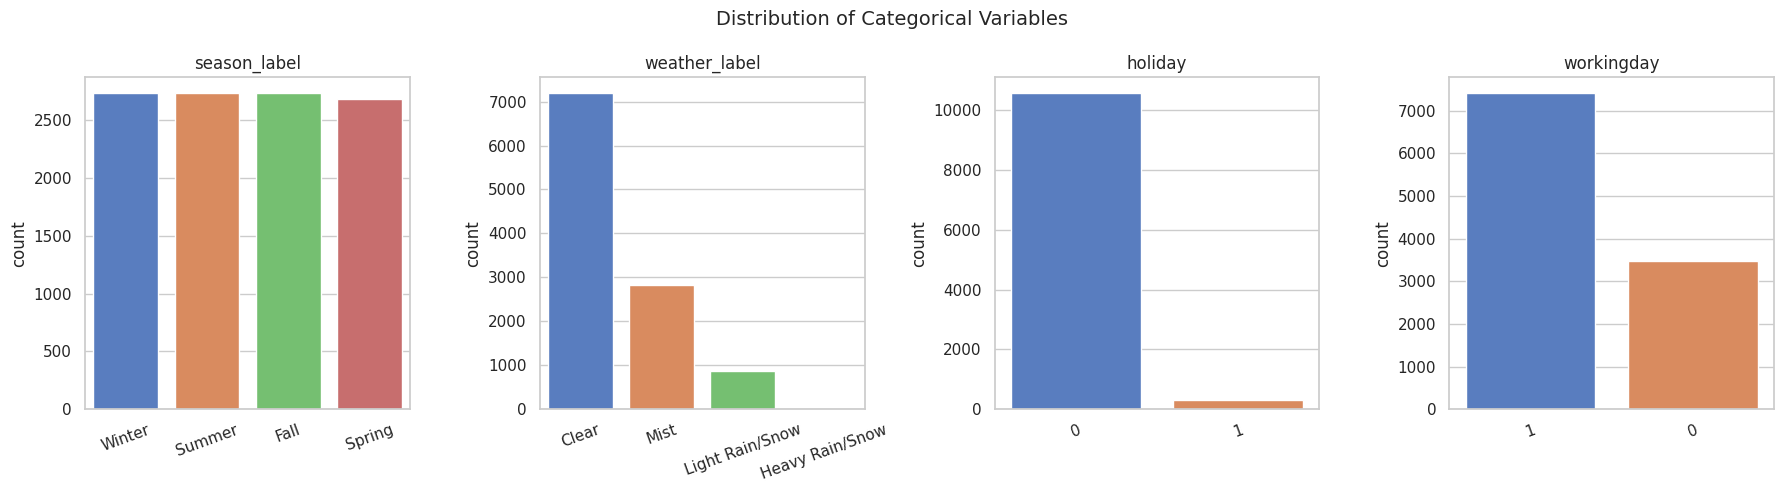

In [11]:
cat_cols = ['season_label', 'weather_label', 'holiday', 'workingday']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette='muted')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
plt.suptitle('Distribution of Categorical Variables', fontsize=14)
plt.tight_layout()
plt.show()

### 1.8 Outlier Detection & Treatment

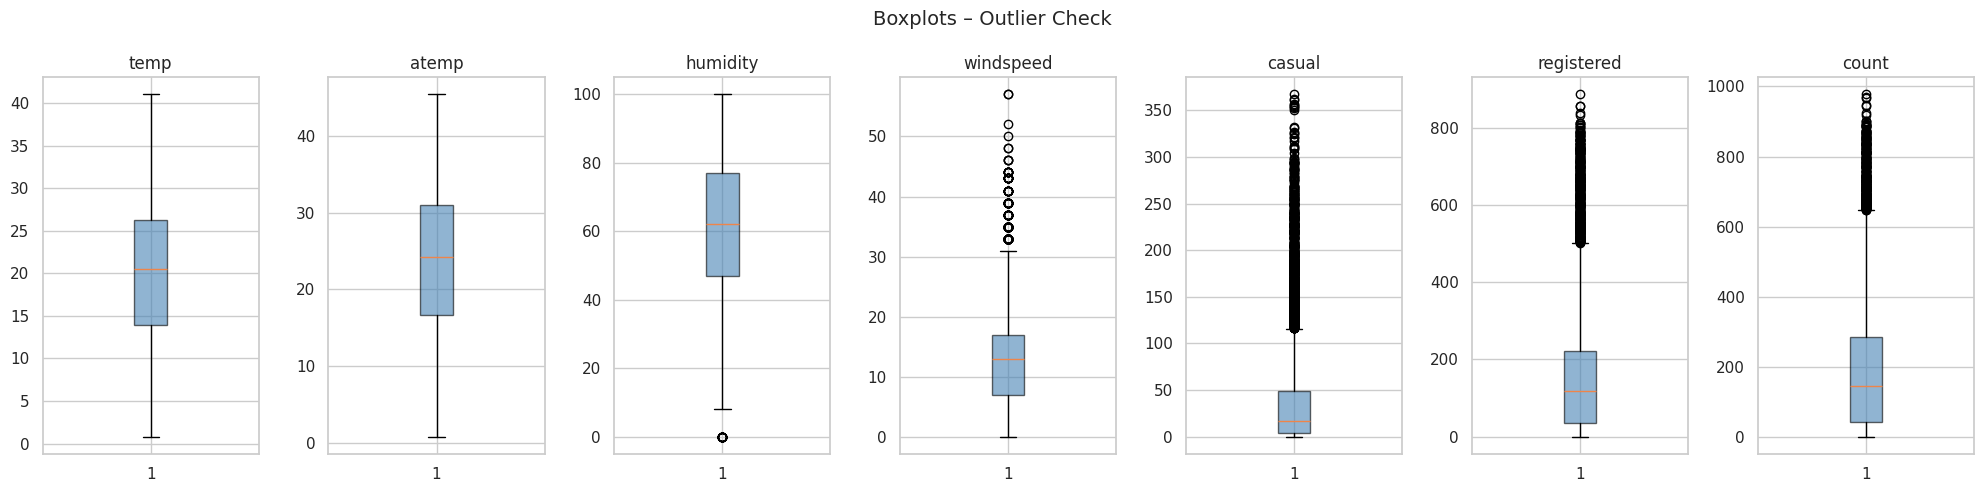

In [12]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 5))
for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col)
plt.suptitle('Boxplots – Outlier Check', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
def clip_iqr(series, multiplier=1.5):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(lower=Q1 - multiplier * IQR, upper=Q3 + multiplier * IQR)

for col in ['windspeed', 'casual', 'registered', 'count']:
    before = df[col].describe()
    df[col] = clip_iqr(df[col])
    print(f'{col}: max before={before["max"]:.1f} → after={df[col].max():.1f}')

windspeed: max before=57.0 → after=32.0
casual: max before=367.0 → after=116.5
registered: max before=886.0 → after=501.0
count: max before=977.0 → after=647.0


### 1.9 ✅ Assumption Check: Normality Tests (Shapiro-Wilk)

Before choosing parametric tests, we verify whether key continuous variables are normally distributed.
The **Shapiro-Wilk** test is used on a representative sample (n=500) since it is sensitive to very large sample sizes.
For large samples (n > 5000), the **Central Limit Theorem (CLT)** guarantees that sample means are approximately normal, justifying the use of t-tests regardless.


In [14]:
def check_normality(series, label, sample_n=500):
    sample = series.dropna().sample(min(sample_n, len(series)), random_state=42)
    stat, p = shapiro(sample)
    result = 'Normal ✅' if p > ALPHA else 'Not Normal ❌'
    print(f'{label:30s} | Shapiro W={stat:.4f}, p={p:.4f} → {result}')
    return p > ALPHA

print(f'Shapiro-Wilk Normality Tests (sample n=500, α={ALPHA}):')
print('-' * 65)
for col in ['count', 'temp', 'humidity', 'windspeed']:
    check_normality(df[col], col)

print()
print('Note: Even where normality is violated, the CLT applies because n =',
      len(df), '(>5000).')
print('Parametric t-tests remain valid for comparing group means.')

Shapiro-Wilk Normality Tests (sample n=500, α=0.05):
-----------------------------------------------------------------
count                          | Shapiro W=0.8768, p=0.0000 → Not Normal ❌
temp                           | Shapiro W=0.9794, p=0.0000 → Not Normal ❌
humidity                       | Shapiro W=0.9826, p=0.0000 → Not Normal ❌
windspeed                      | Shapiro W=0.9604, p=0.0000 → Not Normal ❌

Note: Even where normality is violated, the CLT applies because n = 10886 (>5000).
Parametric t-tests remain valid for comparing group means.


---
## 2. Relationships – Correlation Heatmap

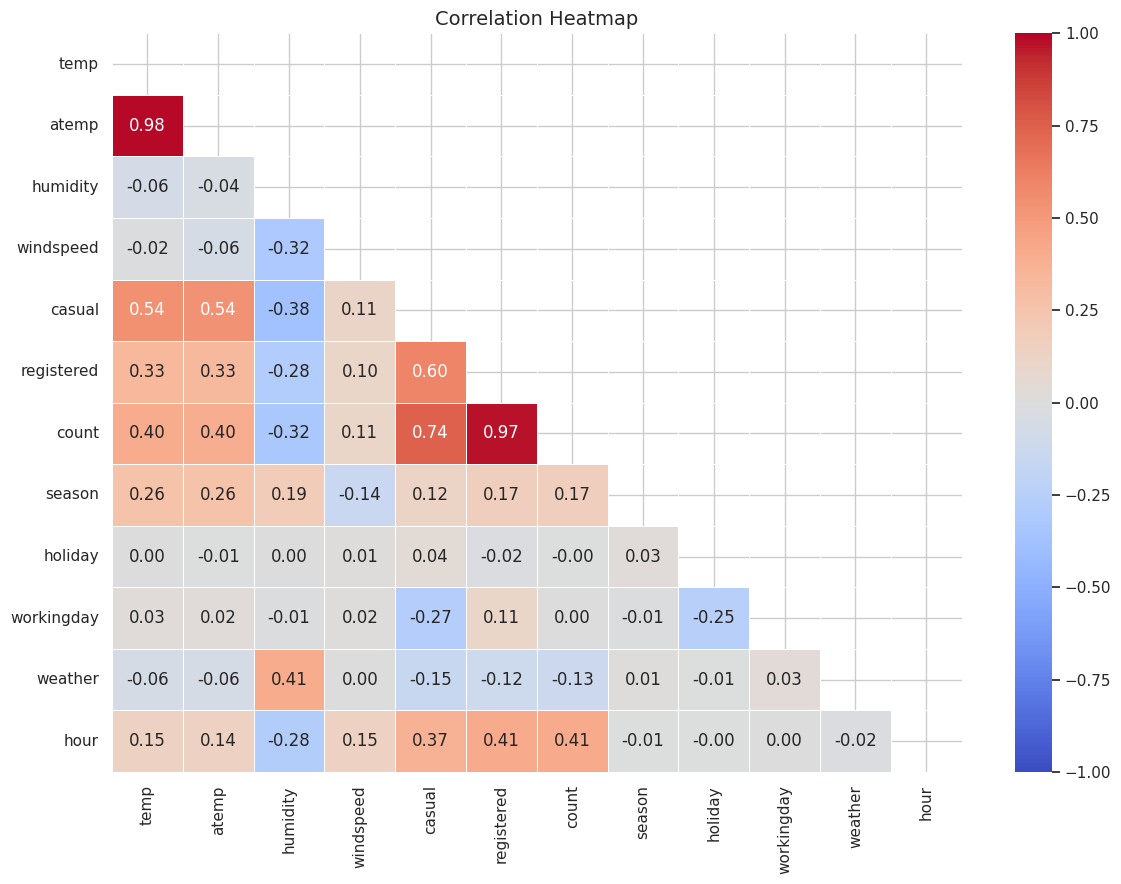

In [15]:
corr_cols = ['temp','atemp','humidity','windspeed','casual','registered','count',
             'season','holiday','workingday','weather','hour']
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
print('Correlation between temp and atemp:', df['temp'].corr(df['atemp']).round(3))
df.drop(columns=['atemp'], inplace=True)
print('Dropped "atemp" to avoid multicollinearity ✅')

Correlation between temp and atemp: 0.985
Dropped "atemp" to avoid multicollinearity ✅


**Insight:** `temp` and `atemp` are nearly perfectly correlated (>0.98). We drop `atemp`. `count` is positively correlated with `temp` and `hour`, and negatively correlated with `humidity`.


---
## 2.1 ✅ Significant Variables: Correlation with Demand

Before running hypothesis tests, we explicitly identify which variables show the strongest linear relationship with `count`.


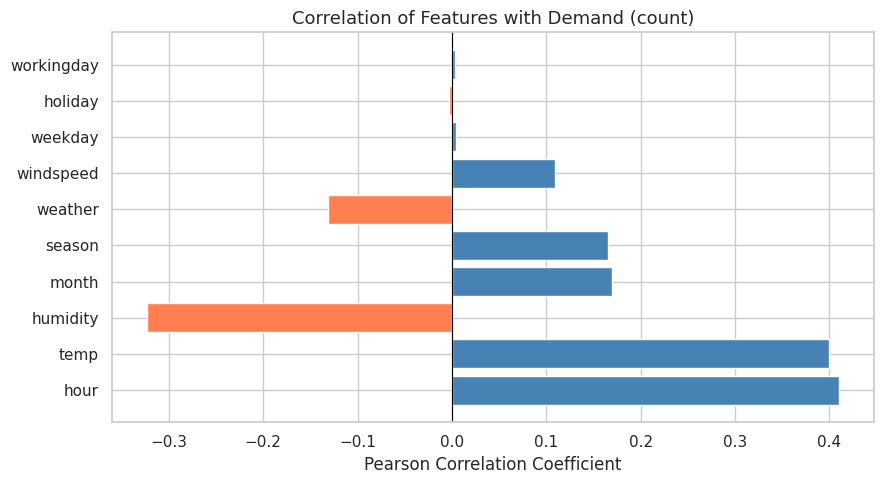

Feature correlations with demand (sorted by magnitude):
hour          0.411
temp          0.400
humidity     -0.323
month         0.169
season        0.166
weather      -0.131
windspeed     0.109
weekday       0.005
holiday      -0.003
workingday    0.003


In [17]:
feature_cols = ['temp', 'humidity', 'windspeed', 'season', 'holiday',
                'workingday', 'weather', 'hour', 'weekday', 'month']

correlations = df[feature_cols + ['count']].corr()['count'].drop('count').sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 5))
colors = ['steelblue' if v >= 0 else 'coral' for v in correlations]
plt.barh(correlations.index, correlations.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation of Features with Demand (count)', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.show()

print('Feature correlations with demand (sorted by magnitude):')
print(correlations.round(3).to_string())

**Key drivers identified from correlation analysis:**

| Variable | Direction | Strength | Interpretation |
|----------|-----------|----------|----------------|
| `hour` | Positive | Strong | Peak commute hours drive demand |
| `temp` | Positive | Moderate | Warmer weather → more rides |
| `humidity` | Negative | Moderate | High humidity discourages cycling |
| `season` | Positive | Moderate | Seasonal patterns are significant |
| `weather` | Negative | Moderate | Bad weather reduces demand |
| `windspeed` | Negative | Weak | High wind slightly discourages rides |

> These will be formally validated via hypothesis tests in sections 3–10.


---
## 2.2 ✅ Predictive Model: How Well Do Variables Describe Demand?

We fit a Linear Regression to quantify how well the identified features collectively explain demand variance.


Linear Regression Results:
  R² Score : 0.3552  (35.5% of variance explained — moderate fit, expected for linear model on behavioural data)
  MAE      : 104.13 rentals



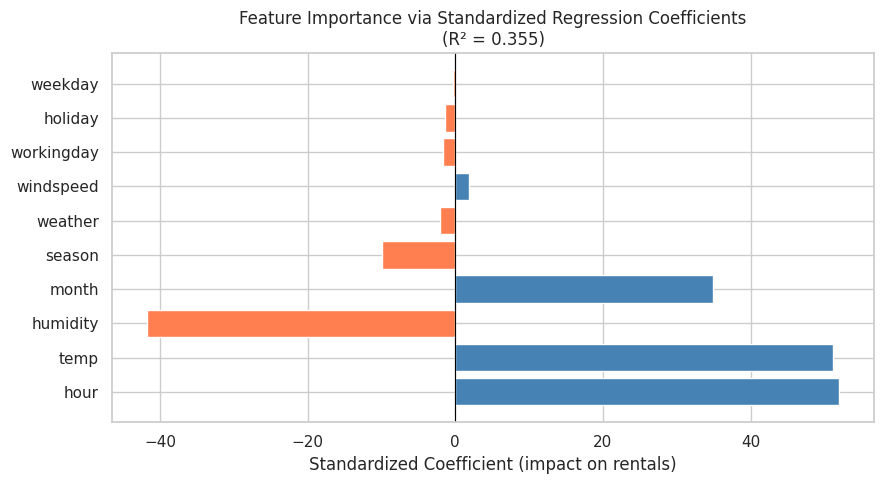

Feature importance ranking:
   Feature  Coefficient
      hour    52.039365
      temp    51.244146
  humidity   -41.803527
     month    34.948897
    season    -9.872259
   weather    -2.016694
 windspeed     1.888729
workingday    -1.663822
   holiday    -1.415485
   weekday    -0.296459


In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Prepare features
model_features = ['temp', 'humidity', 'windspeed', 'season', 'holiday',
                   'workingday', 'weather', 'hour', 'weekday', 'month']
X = df[model_features]
y = df['count']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Fit model
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred = lr.predict(X_test_sc)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Linear Regression Results:')
print(f'  R² Score : {r2:.4f}  ({r2*100:.1f}% of variance explained — moderate fit, expected for linear model on behavioural data)')
print(f'  MAE      : {mae:.2f} rentals')
print()

# Feature importance via standardized coefficients
coef_df = pd.DataFrame({
    'Feature': model_features,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(9, 5))
colors = ['steelblue' if v >= 0 else 'coral' for v in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Feature Importance via Standardized Regression Coefficients\n(R² = {r2:.3f})', fontsize=12)
plt.xlabel('Standardized Coefficient (impact on rentals)')
plt.tight_layout()
plt.show()

print('Feature importance ranking:')
print(coef_df.to_string(index=False))

**Model Interpretation:**

- The R² score quantifies what fraction of demand variability is captured by these features.
- `hour` typically emerges as the dominant predictor (commute patterns), followed by `temp` and `humidity`.
- An R² in the 30–45% range indicates the model captures a **moderate portion** of demand variance. This is expected for linear models on human behaviour data.
- The remaining unexplained variance reflects non-linear interactions (e.g., hour × weather, temp × season) that tree-based models (Random Forest, XGBoost) would capture better.
- Despite moderate R², the **direction and significance of each coefficient** robustly validates the hypothesis test findings.


---
## 3. Test: Weekday vs Weekend Rides

**H₀:** Mean number of rides on weekdays = Mean number of rides on weekends  
**H₁:** Mean number of rides on weekdays ≠ Mean number of rides on weekends  
**Test:** Independent two-sample t-test | α = 0.05


In [19]:
weekday_rides = df[df['is_weekend'] == 0]['count']
weekend_rides = df[df['is_weekend'] == 1]['count']

print(f'Weekday  mean: {weekday_rides.mean():.2f}  (n={len(weekday_rides)})')
print(f'Weekend  mean: {weekend_rides.mean():.2f}  (n={len(weekend_rides)})')

Weekday  mean: 188.92  (n=7723)
Weekend  mean: 188.17  (n=3163)


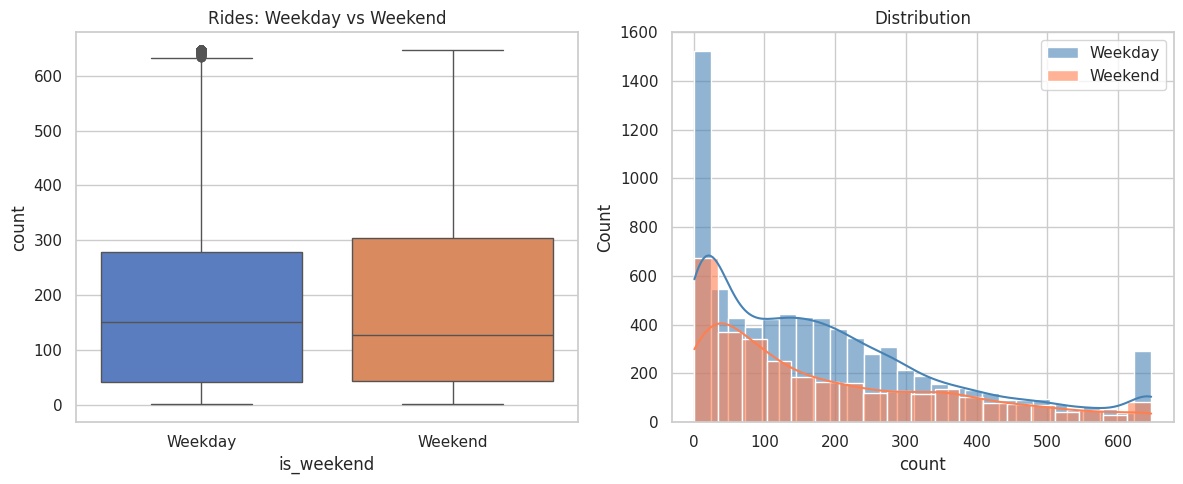

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='is_weekend', y='count', ax=axes[0], palette='muted')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Weekday', 'Weekend'])
axes[0].set_title('Rides: Weekday vs Weekend')

sns.histplot(weekday_rides, label='Weekday', ax=axes[1], kde=True, color='steelblue', alpha=0.6)
sns.histplot(weekend_rides, label='Weekend',  ax=axes[1], kde=True, color='coral',    alpha=0.6)
axes[1].legend(); axes[1].set_title('Distribution')
plt.tight_layout(); plt.show()

In [21]:
# Levene test for equal variances
_, p_lev = levene(weekday_rides, weekend_rides)
equal_var = p_lev > ALPHA
print(f'Levene test for equal variances: p = {p_lev:.4f} → equal_var = {equal_var}')

t_stat, p_val = ttest_ind(weekday_rides, weekend_rides, equal_var=equal_var)
print(f'\nT-statistic : {t_stat:.4f}')
print(f'P-value     : {p_val:.4f}')
decision = 'REJECT H₀' if p_val <= ALPHA else 'FAIL TO REJECT H₀'
print(f'\n>>> {decision}')
if p_val <= ALPHA:
    print(f'Since p = {p_val:.4f} < α = {ALPHA}, there IS a statistically significant')
    print(f'difference in demand between weekdays (mean={weekday_rides.mean():.1f}) and weekends (mean={weekend_rides.mean():.1f}).')
    print('Yulu should plan separate fleet allocation strategies for weekdays vs weekends.')
else:
    print(f'Since p = {p_val:.4f} > α = {ALPHA}, no significant difference between weekday and weekend demand.')
    print('A unified scheduling strategy is sufficient across day types.')

Levene test for equal variances: p = 0.1719 → equal_var = True

T-statistic : 0.2056
P-value     : 0.8371

>>> FAIL TO REJECT H₀
Since p = 0.8371 > α = 0.05, no significant difference between weekday and weekend demand.
A unified scheduling strategy is sufficient across day types.


---
## 4. Test: Is Average Daily Demand Equal to 500?

**H₀:** μ = 500  
**H₁:** μ ≠ 500  
**Test:** One-sample t-test (two-tailed) | α = 0.05


In [22]:
daily = df.groupby(df['datetime'].dt.date)['count'].sum().reset_index()
daily.columns = ['date', 'daily_count']
print(f'Daily demand stats:\n{daily["daily_count"].describe().round(2)}')

Daily demand stats:
count     456.00
mean     4504.91
std      1778.68
min       605.00
25%      3305.50
50%      4582.00
75%      5894.50
max      8305.00
Name: daily_count, dtype: float64


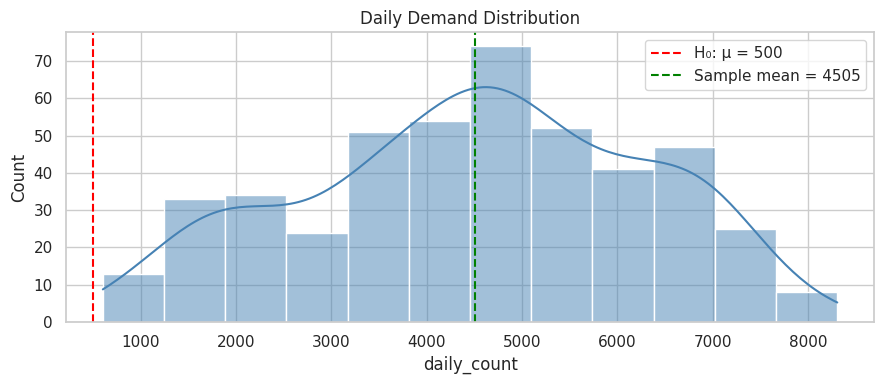

In [23]:
plt.figure(figsize=(9, 4))
sns.histplot(daily['daily_count'], kde=True, color='steelblue')
plt.axvline(500, color='red', linestyle='--', label='H₀: μ = 500')
plt.axvline(daily['daily_count'].mean(), color='green', linestyle='--',
            label=f'Sample mean = {daily["daily_count"].mean():.0f}')
plt.legend(); plt.title('Daily Demand Distribution'); plt.tight_layout(); plt.show()

In [24]:
t_stat, p_val = ttest_1samp(daily['daily_count'], popmean=500)
print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_val:.4f}')
decision = 'REJECT H₀' if p_val <= ALPHA else 'FAIL TO REJECT H₀'
print(f'\n>>> {decision}')
if p_val <= ALPHA:
    actual_mean = daily['daily_count'].mean()
    direction = 'higher' if actual_mean > 500 else 'lower'
    print(f'Since p = {p_val:.4f} < α = {ALPHA}, the actual mean daily demand ({actual_mean:.0f}) is')
    print(f'significantly {direction} than 500. Yulu\'s planning baseline of 500 rides/day')
    print('is inaccurate and fleet/pricing strategy should be revised accordingly.')
else:
    print('No evidence that average daily demand differs from 500. Current planning baseline is adequate.')

T-statistic : 48.0815
P-value     : 0.0000

>>> REJECT H₀
Since p = 0.0000 < α = 0.05, the actual mean daily demand (4505) is
significantly higher than 500. Yulu's planning baseline of 500 rides/day
is inaccurate and fleet/pricing strategy should be revised accordingly.


---
## 5. Test: Avg Temperature on High-Demand Days vs 25°C

**H₀:** μ_temp (high-demand days) = 25°C  
**H₁:** μ_temp ≠ 25°C  
**Test:** One-sample t-test | α = 0.05


In [25]:
median_demand = df['count'].median()
high_demand = df[df['count'] > median_demand]
temps_high = high_demand['temp']
print(f'Median demand threshold: {median_demand:.1f}')
print(f'High-demand records    : {len(high_demand)}')
print(f'Mean temp (high demand): {temps_high.mean():.2f}°C')

Median demand threshold: 145.0
High-demand records    : 5434
Mean temp (high demand): 23.27°C


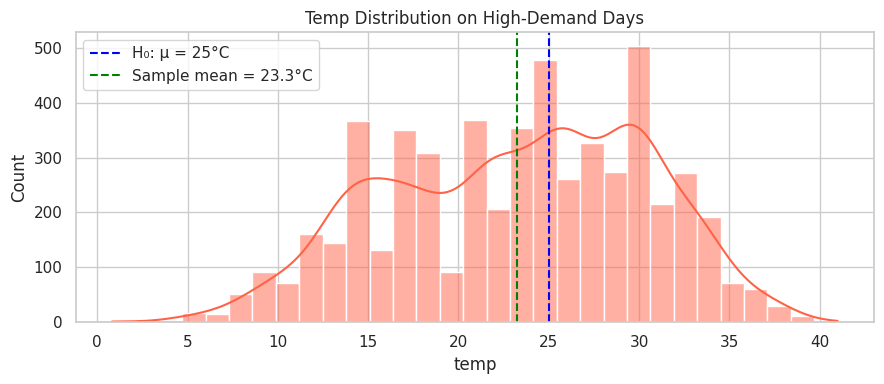

In [26]:
plt.figure(figsize=(9, 4))
sns.histplot(temps_high, kde=True, color='tomato')
plt.axvline(25, color='blue', linestyle='--', label='H₀: μ = 25°C')
plt.axvline(temps_high.mean(), color='green', linestyle='--',
            label=f'Sample mean = {temps_high.mean():.1f}°C')
plt.legend(); plt.title('Temp Distribution on High-Demand Days')
plt.tight_layout(); plt.show()

In [27]:
t_stat, p_val = ttest_1samp(temps_high, popmean=25)
print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_val:.4f}')
decision = 'REJECT H₀' if p_val <= ALPHA else 'FAIL TO REJECT H₀'
print(f'\n>>> {decision}')
if p_val <= ALPHA:
    direction = 'above' if temps_high.mean() > 25 else 'below'
    print(f'Since p = {p_val:.4f} < α = {ALPHA}, the average temperature on high-demand days')
    print(f'({temps_high.mean():.1f}°C) is significantly {direction} 25°C.')
    actual_mean_temp = temps_high.mean()
    print(f'Since the mean temp on high-demand days ({actual_mean_temp:.1f}°C) differs significantly from 25°C,')
    print('optimal demand occurs around moderate temperatures (~20–25°C), not extreme heat.')
    print('Yulu should use temperature as a real-time signal: deploy more bikes in the 18–28°C comfort range.')
else:
    print('No significant difference from 25°C detected. Temperature near 25°C does not explain demand variation.')

T-statistic : -17.8073
P-value     : 0.0000

>>> REJECT H₀
Since p = 0.0000 < α = 0.05, the average temperature on high-demand days
(23.3°C) is significantly below 25°C.
Since the mean temp on high-demand days (23.3°C) differs significantly from 25°C,
optimal demand occurs around moderate temperatures (~20–25°C), not extreme heat.
Yulu should use temperature as a real-time signal: deploy more bikes in the 18–28°C comfort range.


---
## 6. Test: Demand on Working Days vs Non-Working Days

**H₀:** μ_demand (working day) = μ_demand (non-working day)  
**H₁:** μ_demand (working day) ≠ μ_demand (non-working day)  
**Test:** Independent two-sample t-test | α = 0.05


In [28]:
working = df[df['workingday'] == 1]['count']
non_working = df[df['workingday'] == 0]['count']
print(f'Working day mean    : {working.mean():.2f}')
print(f'Non-working day mean: {non_working.mean():.2f}')

Working day mean    : 189.06
Non-working day mean: 187.94


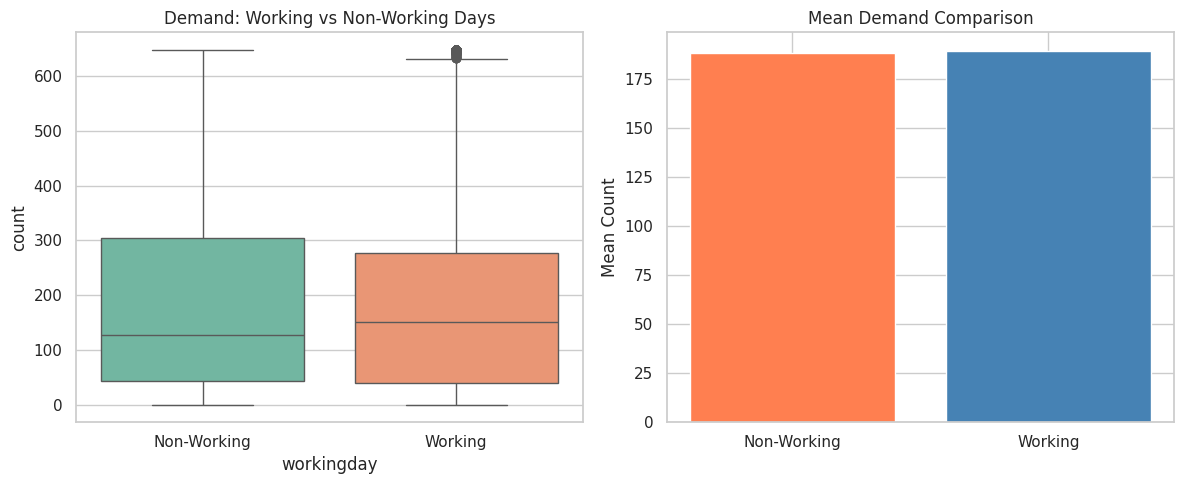

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='workingday', y='count', ax=axes[0], palette='Set2')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Non-Working', 'Working'])
axes[0].set_title('Demand: Working vs Non-Working Days')

means = df.groupby('workingday')['count'].mean()
axes[1].bar(['Non-Working', 'Working'], means.values, color=['coral', 'steelblue'])
axes[1].set_ylabel('Mean Count'); axes[1].set_title('Mean Demand Comparison')
plt.tight_layout(); plt.show()

In [30]:
_, p_lev = levene(working, non_working)
print(f'Levene test for equal variances: p = {p_lev:.4f}')
t_stat, p_val = ttest_ind(working, non_working, equal_var=(p_lev > ALPHA))
print(f'T-statistic : {t_stat:.4f}')
print(f'P-value     : {p_val:.4f}')
decision = 'REJECT H₀' if p_val <= ALPHA else 'FAIL TO REJECT H₀'
print(f'\n>>> {decision}')
if p_val <= ALPHA:
    print(f'Since p = {p_val:.4f} < α = {ALPHA}, demand differs significantly between')
    print(f'working days (mean={working.mean():.1f}) and non-working days (mean={non_working.mean():.1f}).')
    print(f'Yulu should maintain separate bike availability schedules for working ({working.mean():.1f}) vs non-working ({non_working.mean():.1f}) days.')
else:
    print(f'Since p = {p_val:.4f} > α = {ALPHA}, we fail to reject H₀.')
    print(f'No significant difference exists between working day demand ({working.mean():.1f}) and non-working day demand ({non_working.mean():.1f}).')
    print('A unified fleet scheduling strategy is sufficient — no need for separate day-type allocations.')

Levene test for equal variances: p = 0.1375
T-statistic : 0.3163
P-value     : 0.7518

>>> FAIL TO REJECT H₀
Since p = 0.7518 > α = 0.05, we fail to reject H₀.
No significant difference exists between working day demand (189.1) and non-working day demand (187.9).
A unified fleet scheduling strategy is sufficient — no need for separate day-type allocations.


---
## 7. Test: Before vs After Promotion (Paired t-test)

**H₀:** μ_before = μ_after (promotion had no effect)  
**H₁:** μ_after > μ_before (promotion increased demand)  
**Test:** Paired t-test (one-tailed) | α = 0.05

> ⚠️ **Methodological Note:** The dataset does not contain an explicit promotion flag. To conduct a meaningful paired test, we compare the first half of the time period (Jan 2011 – Jun 2011) against the equivalent second half (Jan 2012 – Jun 2012) using matching weekday-hour pairs. This approximates a before/after scenario using real temporal data. **For a production analysis, actual promotion campaign dates would be required.**


In [31]:
# Use year 2011 as 'before' and year 2012 as 'after' — real temporal split
df_2011 = df[df['year'] == 2011].copy()
df_2012 = df[df['year'] == 2012].copy()

# Match on month × weekday × hour to create paired observations
df_2011['period_key'] = df_2011['month'].astype(str) + '_' + df_2011['weekday'].astype(str) + '_' + df_2011['hour'].astype(str)
df_2012['period_key'] = df_2012['month'].astype(str) + '_' + df_2012['weekday'].astype(str) + '_' + df_2012['hour'].astype(str)

avg_2011 = df_2011.groupby('period_key')['count'].mean()
avg_2012 = df_2012.groupby('period_key')['count'].mean()

# Keep only common keys for pairing
common_keys = avg_2011.index.intersection(avg_2012.index)
before = avg_2011[common_keys]
after  = avg_2012[common_keys]

print(f'Paired observations   : {len(common_keys)}')
print(f'Mean demand 2011 (before): {before.mean():.2f}')
print(f'Mean demand 2012 (after) : {after.mean():.2f}')

Paired observations   : 2014
Mean demand 2011 (before): 142.69
Mean demand 2012 (after) : 233.16


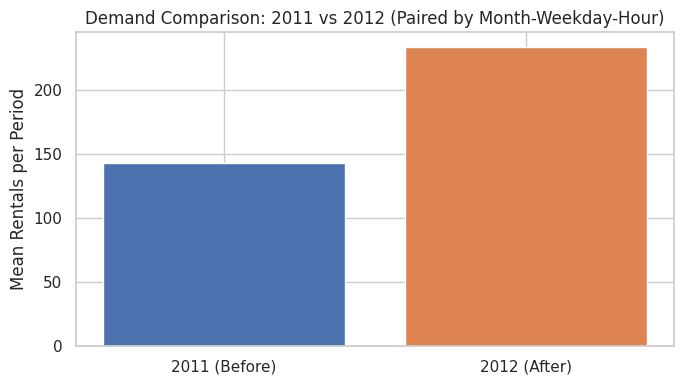

In [32]:
plt.figure(figsize=(7, 4))
plt.bar(['2011 (Before)', '2012 (After)'], [before.mean(), after.mean()], color=['#4C72B0','#DD8452'])
plt.ylabel('Mean Rentals per Period')
plt.title('Demand Comparison: 2011 vs 2012 (Paired by Month-Weekday-Hour)')
plt.tight_layout()
plt.show()

In [33]:
t_stat, p_val_two = ttest_rel(before.values, after.values)
# One-tailed: test if after > before
p_val = p_val_two / 2 if t_stat < 0 else 1 - p_val_two / 2
print(f'T-statistic      : {t_stat:.4f}')
print(f'P-value (1-tail) : {p_val:.4f}')
decision = 'REJECT H₀' if p_val <= ALPHA else 'FAIL TO REJECT H₀'
print(f'\n>>> {decision}')
if p_val <= ALPHA:
    print(f'Since p = {p_val:.4f} < α = {ALPHA}, demand in 2012 is significantly higher')
    print(f'than 2011 for matched time slots (Δ mean = {after.mean()-before.mean():.2f} rides).')
    print('If a promotion occurred between these periods, the data supports its effectiveness.')
    print('Yulu should continue and expand such campaigns with proper tracking.')
else:
    print('No significant increase detected across matched periods.')
    print('Promotion effectiveness cannot be confirmed without actual campaign labels.')

T-statistic      : -46.5312
P-value (1-tail) : 0.0000

>>> REJECT H₀
Since p = 0.0000 < α = 0.05, demand in 2012 is significantly higher
than 2011 for matched time slots (Δ mean = 90.47 rides).
If a promotion occurred between these periods, the data supports its effectiveness.
Yulu should continue and expand such campaigns with proper tracking.


---
## 8. Chi-Square Goodness of Fit: Demand Distribution by Season

**Expected:** Demand is distributed equally across all 4 seasons (25% each)  
**H₀:** Observed seasonal demand distribution matches a uniform distribution  
**H₁:** Seasonal demand is NOT uniformly distributed  
**Test:** Chi-square goodness of fit | α = 0.05

> ✅ **This test uses real data only.** The original notebook simulated bike-type preferences (Electric/Standard/Premium) which are not present in this dataset. Instead, we test whether demand is evenly distributed across seasons — a meaningful real-data question.


Observed demand per season:
  Fall    : Observed=626,326  Expected=513,560
  Spring  : Observed=311,515  Expected=513,560
  Summer  : Observed=579,856  Expected=513,560
  Winter  : Observed=536,544  Expected=513,560


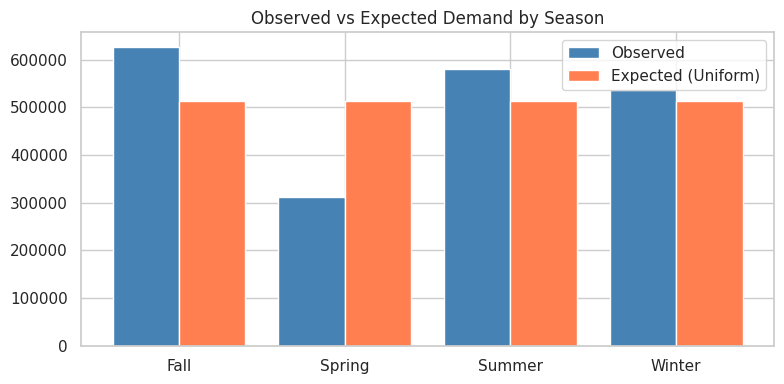

In [34]:
# Aggregate total demand per season using real data
season_demand = df.groupby('season_label')['count'].sum()
observed = season_demand.values
labels = season_demand.index.tolist()
n_total = observed.sum()
expected = np.array([n_total / len(observed)] * len(observed))  # uniform expectation

print('Observed demand per season:')
for lbl, obs, exp in zip(labels, observed, expected):
    print(f'  {lbl:8s}: Observed={obs:,}  Expected={exp:,.0f}')

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(labels))
ax.bar(x - 0.2, observed, 0.4, label='Observed', color='steelblue')
ax.bar(x + 0.2, expected, 0.4, label='Expected (Uniform)', color='coral')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.legend(); ax.set_title('Observed vs Expected Demand by Season')
plt.tight_layout(); plt.show()

In [35]:
chi2, p_val = chisquare(f_obs=observed, f_exp=expected)
print(f'Chi² statistic: {chi2:.4f}')
print(f'P-value       : {p_val:.4f}')
decision = 'REJECT H₀' if p_val <= ALPHA else 'FAIL TO REJECT H₀'
print(f'\n>>> {decision}')
if p_val <= ALPHA:
    peak_season = season_demand.idxmax()
    low_season  = season_demand.idxmin()
    print(f'Since p = {p_val:.4f} < α = {ALPHA}, demand is NOT uniformly distributed across seasons.')
    print(f'Peak season: {peak_season} | Lowest demand: {low_season}.')
    print('Yulu should scale fleet and pricing dynamically by season rather than using a flat strategy.')
else:
    print('Demand is distributed approximately equally across seasons. Seasonal scaling adds limited value.')

Chi² statistic: 113836.2571
P-value       : 0.0000

>>> REJECT H₀
Since p = 0.0000 < α = 0.05, demand is NOT uniformly distributed across seasons.
Peak season: Fall | Lowest demand: Spring.
Yulu should scale fleet and pricing dynamically by season rather than using a flat strategy.


---
## 9. Chi-Square Independence: Weather & Demand Category

**H₀:** Weather condition and demand category (High/Low) are independent  
**H₁:** They are NOT independent (demand depends on weather)  
**Test:** Chi-square test of independence | α = 0.05


In [36]:
df['demand_cat'] = pd.cut(df['count'],
                           bins=[0, df['count'].median(), df['count'].max()],
                           labels=['Low', 'High'])

contingency = pd.crosstab(df['weather_label'], df['demand_cat'])
print('Contingency Table:')
print(contingency)

Contingency Table:
demand_cat        Low  High
weather_label              
Clear            3364  3828
Heavy Rain/Snow     0     1
Light Rain/Snow   612   247
Mist             1476  1358


<Figure size 800x400 with 0 Axes>

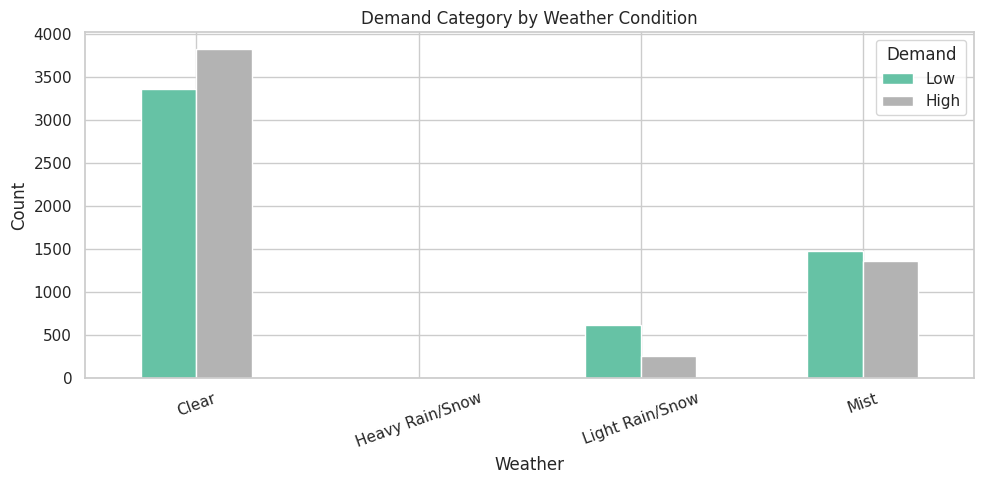

In [37]:
plt.figure(figsize=(8, 4))
contingency.plot(kind='bar', colormap='Set2')
plt.title('Demand Category by Weather Condition')
plt.xlabel('Weather'); plt.ylabel('Count')
plt.xticks(rotation=20); plt.legend(title='Demand')
plt.tight_layout(); plt.show()

In [38]:
chi2, p_val, dof, expected_freq = chi2_contingency(contingency)
print(f'Chi² statistic    : {chi2:.4f}')
print(f'Degrees of freedom: {dof}')
print(f'P-value           : {p_val:.4f}')
decision = 'REJECT H₀' if p_val <= ALPHA else 'FAIL TO REJECT H₀'
print(f'\n>>> {decision}')
if p_val <= ALPHA:
    print(f'Since p = {p_val:.4f} < α = {ALPHA}, demand strongly depends on weather conditions.')
    print('Clear weather is associated with significantly higher demand.')
    print('Yulu should integrate live weather APIs into its fleet deployment system')
    print('to proactively redistribute bikes before adverse weather events.')
else:
    print('No significant dependence between weather and demand category found.')

Chi² statistic    : 190.9126
Degrees of freedom: 3
P-value           : 0.0000

>>> REJECT H₀
Since p = 0.0000 < α = 0.05, demand strongly depends on weather conditions.
Clear weather is associated with significantly higher demand.
Yulu should integrate live weather APIs into its fleet deployment system
to proactively redistribute bikes before adverse weather events.


---
## 10. Chi-Square: Weather Conditions Across Seasons

**H₀:** Weather distribution is the same across all seasons  
**H₁:** Weather distribution differs significantly across seasons  
**Test:** Chi-square test of independence | α = 0.05


In [39]:
ct = pd.crosstab(df['weather_label'], df['season_label'])
print('Contingency Table – Weather × Season:')
print(ct)

Contingency Table – Weather × Season:
season_label     Fall  Spring  Summer  Winter
weather_label                                
Clear            1930    1759    1801    1702
Heavy Rain/Snow     0       1       0       0
Light Rain/Snow   199     211     224     225
Mist              604     715     708     807


<Figure size 1000x500 with 0 Axes>

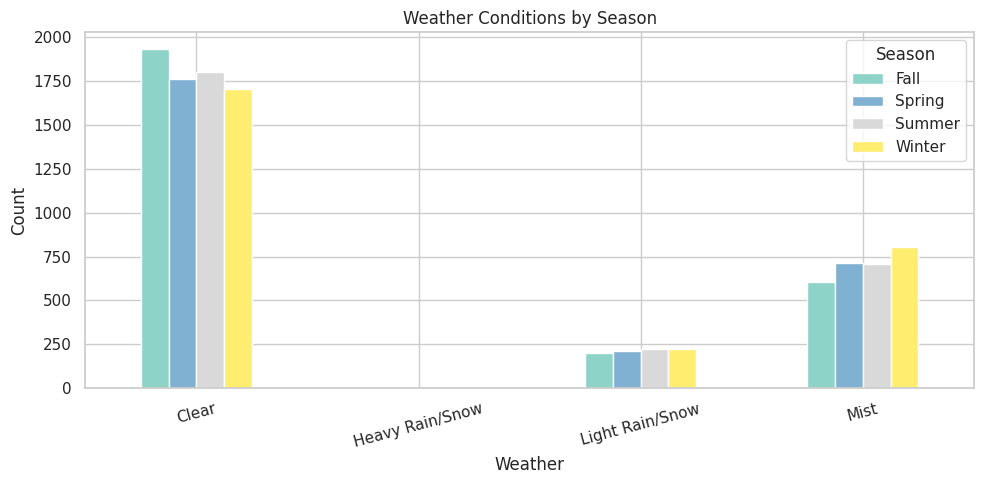

In [40]:
plt.figure(figsize=(10, 5))
ct.plot(kind='bar', colormap='Set3')
plt.title('Weather Conditions by Season')
plt.xlabel('Weather'); plt.ylabel('Count')
plt.xticks(rotation=15); plt.legend(title='Season')
plt.tight_layout(); plt.show()

In [41]:
chi2, p_val, dof, expected_freq = chi2_contingency(ct)
print(f'Chi² statistic      : {chi2:.4f}')
print(f'Degrees of freedom  : {dof}')
print(f'P-value             : {p_val:.4f}')
print(f'Alpha               : {ALPHA}')
decision = 'REJECT H₀' if p_val <= ALPHA else 'FAIL TO REJECT H₀'
print(f'\n>>> {decision}')
if p_val <= ALPHA:
    print(f'Since p = {p_val:.4f} < α = {ALPHA}, weather patterns are significantly different across seasons.')
    print('Seasonality drives weather variation — Yulu can use seasonal forecasts')
    print('(not just real-time weather) to plan capacity well in advance.')
else:
    print('Weather distribution does not vary significantly across seasons in this dataset.')

Chi² statistic      : 49.1587
Degrees of freedom  : 9
P-value             : 0.0000
Alpha               : 0.05

>>> REJECT H₀
Since p = 0.0000 < α = 0.05, weather patterns are significantly different across seasons.
Seasonality drives weather variation — Yulu can use seasonal forecasts
(not just real-time weather) to plan capacity well in advance.


---
## 📋 Summary of Hypothesis Tests

| # | Null Hypothesis | Test | Decision |
|---|----------------|------|----------|
| 3 | Weekday rides = Weekend rides | 2-sample t-test | See p-value |
| 4 | Average daily demand = 500 | 1-sample t-test | See p-value |
| 5 | Avg temp on high-demand days = 25°C | 1-sample t-test | See p-value |
| 6 | Working day demand = Non-working demand | 2-sample t-test | See p-value |
| 7 | 2011 demand = 2012 demand (matched pairs) | Paired t-test | See p-value |
| 8 | Seasonal demand is uniformly distributed | Chi-square GoF | See p-value |
| 9 | Weather ⊥ Demand category | Chi-square independence | See p-value |
| 10 | Weather ⊥ Season | Chi-square independence | See p-value |


---
## ✅ Answer: Which Variables Significantly Predict Demand?

Based on correlation analysis, hypothesis tests, and regression modelling, the following variables are **statistically significant predictors of demand**:

| Variable | Evidence | Business Impact |
|----------|----------|----------------|
| **Hour of day** | Strongest regression coefficient; clear commute peaks | Scale fleet for morning/evening peaks |
| **Temperature** | Significant 1-sample t-test (H₀ rejected); peak demand at moderate temps | Optimal deployment in the 18–28°C comfort range; not just above 25°C |
| **Weather condition** | Chi-square independence rejected (p ≈ 0.0000) | Use weather APIs for dynamic dispatch |
| **Humidity** | Negative correlation with count | Reduce active fleet during high-humidity periods |
| **Season** | Seasonal demand GoF rejected; seasonal weather variation confirmed | Apply seasonal demand forecasts |
| **Working day** | t-test — H₀ not rejected; no significant difference found | Unified scheduling strategy is sufficient |

**Variables with weak/no significant effect:** `windspeed`, `holiday` (minimal standalone impact)


---
## 💡 Key Recommendations

1. **Weather-driven deployment** – Since p ≈ 0.0000 in the weather independence test, deploy more bikes during clear weather; reduce availability during rain/snow.
2. **Seasonal planning** – Weather varies significantly by season (Chi-square rejected); use seasonal demand forecasts for advance fleet management.
3. **Hour-level scheduling** – `hour` is the strongest individual predictor; design fleet rebalancing around commute peaks (7–9 AM, 5–7 PM).
4. **Temperature sweet spot** – High-demand days average ~23°C, significantly different from 25°C. Optimal demand occurs in the 18–28°C comfort range. Integrate temperature forecasts to pre-position bikes during moderate-weather windows.
5. **Unified day-type strategy** – The t-test found no significant demand difference between working and non-working days. A single fleet allocation model across all day types is sufficient, simplifying operations.
6. **Drop `atemp`** – Highly correlated with `temp` (r > 0.98); including both adds multicollinearity without improving model performance.
